# Ames House Price Prediction
## Oasis Infobyte — Data Analytics Internship
### Level 2 – Task 1: Predicting House Prices with Linear Regression

**Author:** Vikas Gaikwad

### Project Objective
Build and evaluate a Linear Regression model to predict house sale prices
in Ames, Iowa, using property characteristics such as living area,
neighborhood, overall quality, number of rooms, and property age.

The project includes:
- Inspecting and cleaning the dataset.
- Exploring price distributions and relationships between variables.
- Selecting relevant features and encoding categorical variables.
- Splitting the data into 80% training and 20% testing sets.
- Evaluating predictions using MSE, RMSE, and R².
- Examining residuals and interpreting model coefficients.

**Target variable:** SalePrice — house sale price in US dollars.

In [2]:
# libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Preserve the text "None" as a valid category
# Treat "NA" and empty cells as missing values
df_raw = pd.read_csv(
    r"C:\Desktop\OIBSIP\DataAnalytics-L2-HousePricePrediction\Dataset\train.csv",
    keep_default_na=False,
    na_values=["NA", ""]
)

# Create the working copy
df = df_raw.copy()

In [4]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
# Rename selected columns to make their meanings easier to understand
column_mapping = {
    "Id": "Property_ID",
    "SalePrice": "Sale_Price",
    "PoolQC": "Pool_Quality",
    "PoolArea": "Pool_Area_SqFt",
    "FireplaceQu": "Fireplace_Quality",
    "Fireplaces": "Fireplace_Count",
    "GarageQual": "Garage_Quality",
    "GarageCars": "Garage_Car_Capacity",
    "BsmtQual": "Basement_Height_Rating",
    "TotalBsmtSF": "Total_Basement_Area_SqFt"
}

# Apply the new names to the working dataframe
df = df.rename(columns=column_mapping)

# Display the renamed columns to verify the changes
df[list(column_mapping.values())].head()

,Property_ID,Sale_Price,Pool_Quality,Pool_Area_SqFt,Fireplace_Quality,Fireplace_Count,Garage_Quality,Garage_Car_Capacity,Basement_Height_Rating,Total_Basement_Area_SqFt
0,1,208500,NaN,0,NaN,0,TA,2,Gd,856
1,2,181500,NaN,0,TA,1,TA,2,Gd,1262
2,3,223500,NaN,0,TA,1,TA,2,Gd,920
3,4,140000,NaN,0,Gd,1,TA,3,TA,756
4,5,250000,NaN,0,TA,1,TA,3,Gd,1145


In [6]:
# Checking dataset dimensions and whether the target has missing values
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing sale prices:", df["Sale_Price"].isna().sum())

# Confirm that each record has a unique ID
print("Are Property_ID unique?", df["Property_ID"].is_unique)

Rows: 1460
Columns: 81
Missing sale prices: 0
Are Property_ID unique? True


In [7]:
# Displaying every column with its non-null count and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Property_ID               1460 non-null   int64  
 1   MSSubClass                1460 non-null   int64  
 2   MSZoning                  1460 non-null   object 
 3   LotFrontage               1201 non-null   float64
 4   LotArea                   1460 non-null   int64  
 5   Street                    1460 non-null   object 
 6   Alley                     91 non-null     object 
 7   LotShape                  1460 non-null   object 
 8   LandContour               1460 non-null   object 
 9   Utilities                 1460 non-null   object 
 10  LotConfig                 1460 non-null   object 
 11  LandSlope                 1460 non-null   object 
 12  Neighborhood              1460 non-null   object 
 13  Condition1                1460 non-null   object 
 14  Conditio

In [8]:
# Calculate missing-value counts and percentages for each column
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

# Show only columns with missing values, highest count first
missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Pool_Quality,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
Fireplace_Quality,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55
Garage_Quality,81,5.55


In [9]:
# Confirm that "None" remains a valid category
# dropna=False also displays the missing-value count
df["MasVnrType"].value_counts(dropna=False)

MasVnrType
None       864
BrkFace    445
Stone      128
BrkCmn      15
NaN          8
Name: count, dtype: int64

In [10]:
# Check for repeated IDs
print("Duplicate IDs:", df["Property_ID"].duplicated().sum())

# Check for identical records without letting unique IDs hide duplicates
print(
    "Duplicate rows excluding Id:",
    df.drop(columns=["Property_ID"]).duplicated().sum()
)

Duplicate IDs: 0
Duplicate rows excluding Id: 0


In [11]:
# Compare missing quality ratings with related feature measurements
# A missing rating with a positive measurement needs further investigation
feature_checks = [
    ("Pool_Quality", "Pool_Area_SqFt"),
    ("Fireplace_Quality", "Fireplace_Count"),
    ("Garage_Quality", "Garage_Car_Capacity"),
    ("Basement_Height_Rating", "Total_Basement_Area_SqFt")
]

for quality_col, amount_col in feature_checks:
    missing = df[quality_col].isna()

    print(f"\n{quality_col}:")
    print("Missing ratings:", missing.sum())
    print(
        "Missing rating with zero measurement:",
        (missing & df[amount_col].eq(0)).sum()
    )
    print(
        "Missing rating with positive measurement:",
        (missing & df[amount_col].gt(0)).sum()
    )


Pool_Quality:
Missing ratings: 1453
Missing rating with zero measurement: 1453
Missing rating with positive measurement: 0

Fireplace_Quality:
Missing ratings: 690
Missing rating with zero measurement: 690
Missing rating with positive measurement: 0

Garage_Quality:
Missing ratings: 81
Missing rating with zero measurement: 81
Missing rating with positive measurement: 0

Basement_Height_Rating:
Missing ratings: 37
Missing rating with zero measurement: 37
Missing rating with positive measurement: 0


In [12]:
# Define labels for features confirmed to be absent
absence_rules = [
    ("Pool_Quality", "Pool_Area_SqFt", "NoPool"),
    ("Fireplace_Quality", "Fireplace_Count", "NoFireplace"),
    ("Garage_Quality", "Garage_Car_Capacity", "NoGarage"),
    ("Basement_Height_Rating", "Total_Basement_Area_SqFt", "NoBasement")
]

# Replace missing ratings only where the related measurement is zero
for rating_col, measurement_col, label in absence_rules:
    mask = df[rating_col].isna() & df[measurement_col].eq(0)
    df.loc[mask, rating_col] = label

In [13]:
# Check that these four columns no longer contain missing ratings
checked_columns = [
    "Pool_Quality",
    "Fireplace_Quality",
    "Garage_Quality",
    "Basement_Height_Rating"
]

df[checked_columns].isna().sum()

Pool_Quality              0
Fireplace_Quality         0
Garage_Quality            0
Basement_Height_Rating    0
dtype: int64

In [14]:
# Checking remaining missing values in the entire dataset
missing_values = df.isna().sum()

# Only columns that still contain missing values
missing_values[missing_values > 0].sort_values(ascending=False)


MiscFeature     1406
Alley           1369
Fence           1179
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtFinType1      37
MasVnrType         8
MasVnrArea         8
Electrical         1
dtype: int64

In [15]:
# Fill missing values where NaN means the house does not have that feature

none_columns = [
    "MiscFeature",
    "Alley",
    "Fence",
    "GarageType",
    "GarageFinish",
    "GarageCond",
    "BsmtExposure",
    "BsmtFinType2",
    "BsmtCond",
    "BsmtFinType1"
]

for col in none_columns:
    df[col] = df[col].fillna("None")

print("Missing categorical feature values handled successfully.")


Missing categorical feature values handled successfully.


In [16]:
# Missing GarageYrBlt means the property has no garage
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [17]:
# Fill LotFrontage with its median value
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

# Missing MasVnrArea means no masonry veneer
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [18]:
# Fill the single missing Electrical value with the most frequent category
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [19]:
# Missing MasVnrType means the property has no masonry veneer
df["MasVnrType"] = df["MasVnrType"].fillna("None")

In [20]:
# Check remaining missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [21]:
# Check the data types of all columns

df.dtypes

Property_ID        int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
Sale_Price         int64
Length: 81, dtype: object

In [22]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns

print("Number of categorical columns:", len(categorical_columns))
print("\nCategorical columns:")
print(list(categorical_columns))

Number of categorical columns: 43

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'Basement_Height_Rating', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplace_Quality', 'GarageType', 'GarageFinish', 'Garage_Quality', 'GarageCond', 'PavedDrive', 'Pool_Quality', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [23]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical columns:", len(numerical_columns))
print("\nNumerical columns:")
print(list(numerical_columns))

Number of numerical columns: 38

Numerical columns:
['Property_ID', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'Total_Basement_Area_SqFt', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplace_Count', 'GarageYrBlt', 'Garage_Car_Capacity', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'Pool_Area_SqFt', 'MiscVal', 'MoSold', 'YrSold', 'Sale_Price']


In [24]:
# Check the number of unique values in each categorical column

categorical_summary = pd.DataFrame({
    "Unique_Values": df[categorical_columns].nunique(),
    "Missing_Values": df[categorical_columns].isnull().sum()
}).sort_values("Unique_Values", ascending=False)

categorical_summary

,Unique_Values,Missing_Values
Neighborhood,25,0
Exterior2nd,16,0
Exterior1st,15,0
SaleType,9,0
Condition1,9,0
RoofMatl,8,0
Condition2,8,0
HouseStyle,8,0
BsmtFinType2,7,0
Functional,7,0


In [25]:
# Display unique values of important ordinal/quality-related columns

ordinal_columns = [
    'ExterQual',
    'KitchenQual',
    'HeatingQC',
    'Garage_Quality',
    'Fireplace_Quality',
    'Pool_Quality',
    'Basement_Height_Rating',
    'BsmtExposure',
    'BsmtCond',
    'GarageCond',
    'GarageFinish',
    'BsmtFinType1',
    'BsmtFinType2'
]

for col in ordinal_columns:
    print(f"\n{col}:")
    print(df[col].unique())


ExterQual:
['Gd' 'TA' 'Ex' 'Fa']

KitchenQual:
['Gd' 'TA' 'Ex' 'Fa']

HeatingQC:
['Ex' 'Gd' 'TA' 'Fa' 'Po']

Garage_Quality:
['TA' 'Fa' 'Gd' 'NoGarage' 'Ex' 'Po']

Fireplace_Quality:
['NoFireplace' 'TA' 'Gd' 'Fa' 'Ex' 'Po']

Pool_Quality:
['NoPool' 'Ex' 'Fa' 'Gd']

Basement_Height_Rating:
['Gd' 'TA' 'Ex' 'NoBasement' 'Fa']

BsmtExposure:
['No' 'Gd' 'Mn' 'Av' 'None']

BsmtCond:
['TA' 'Gd' 'None' 'Fa' 'Po']

GarageCond:
['TA' 'Fa' 'None' 'Gd' 'Po' 'Ex']

GarageFinish:
['RFn' 'Unf' 'Fin' 'None']

BsmtFinType1:
['GLQ' 'ALQ' 'Unf' 'Rec' 'BLQ' 'None' 'LwQ']

BsmtFinType2:
['Unf' 'BLQ' 'None' 'ALQ' 'Rec' 'LwQ' 'GLQ']


In [26]:
# Ordinal encoding for quality and condition-related categorical columns

ordinal_mappings = {

    'ExterQual': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2
    },

    'KitchenQual': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2
    },

    'HeatingQC': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'Po': 1
    },

    'Garage_Quality': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'Po': 1,
        'NoGarage': 0
    },

    'Fireplace_Quality': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'Po': 1,
        'NoFireplace': 0
    },

    'Pool_Quality': {
        'Ex': 3,
        'Gd': 2,
        'Fa': 1,
        'NoPool': 0
    },

    'Basement_Height_Rating': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'NoBasement': 0
    },

    'BsmtExposure': {
        'Gd': 4,
        'Av': 3,
        'Mn': 2,
        'No': 1,
        'None': 0
    },

    'BsmtCond': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'Po': 1,
        'None': 0
    },

    'GarageCond': {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'Po': 1,
        'None': 0
    },

    'GarageFinish': {
        'Fin': 3,
        'RFn': 2,
        'Unf': 1,
        'None': 0
    },

    'BsmtFinType1': {
        'GLQ': 6,
        'ALQ': 5,
        'BLQ': 4,
        'Rec': 3,
        'LwQ': 2,
        'Unf': 1,
        'None': 0
    },

    'BsmtFinType2': {
        'GLQ': 6,
        'ALQ': 5,
        'BLQ': 4,
        'Rec': 3,
        'LwQ': 2,
        'Unf': 1,
        'None': 0
    }
}


# Apply the mappings
for column, mapping in ordinal_mappings.items():
    df[column] = df[column].map(mapping)


# Check the result
df[ordinal_columns].head()

,ExterQual,KitchenQual,HeatingQC,Garage_Quality,Fireplace_Quality,Pool_Quality,Basement_Height_Rating,BsmtExposure,BsmtCond,GarageCond,GarageFinish,BsmtFinType1,BsmtFinType2
0,4,4,5,3,0,0,4,1,3,3,2,6,1
1,3,3,5,3,3,0,4,4,3,3,2,5,1
2,4,4,5,3,3,0,4,2,3,3,2,6,1
3,3,4,4,3,4,0,3,1,4,3,1,5,1
4,4,4,5,3,3,0,4,3,3,3,2,6,1


In [27]:
# Find remaining categorical columns

remaining_categorical = df.select_dtypes(include=['object']).columns.tolist()

print("Remaining categorical columns:")
print(remaining_categorical)

print("\nNumber of remaining categorical columns:", len(remaining_categorical))

Remaining categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Number of remaining categorical columns: 30


In [28]:
# One-Hot Encode remaining categorical columns

df = pd.get_dummies(
    df,
    columns=remaining_categorical,
    drop_first=True,
    dtype=int
)

print("Dataset shape after encoding:", df.shape)

Dataset shape after encoding: (1460, 219)


In [29]:
drop_first=True

In [30]:
# Check remaining categorical columns

remaining_categorical = df.select_dtypes(include=['object']).columns.tolist()

print("Remaining categorical columns:", remaining_categorical)
print("Number:", len(remaining_categorical))

Remaining categorical columns: []
Number: 0


In [31]:
# Calculate correlation of all numerical features with Sale_Price

correlation_with_price = df.corr(numeric_only=True)['Sale_Price'].sort_values(
    ascending=False
)

print("Top 15 features positively correlated with Sale_Price:")
print(correlation_with_price.head(16))

print("\nTop 10 features negatively correlated with Sale_Price:")
print(correlation_with_price.sort_values().head(10))

Top 15 features positively correlated with Sale_Price:
Sale_Price                  1.000000
OverallQual                 0.790982
GrLivArea                   0.708624
ExterQual                   0.682639
KitchenQual                 0.659600
Garage_Car_Capacity         0.640409
GarageArea                  0.623431
Total_Basement_Area_SqFt    0.613581
1stFlrSF                    0.605852
Basement_Height_Rating      0.585207
FullBath                    0.560664
GarageFinish                0.549247
TotRmsAbvGrd                0.533723
YearBuilt                   0.522897
Fireplace_Quality           0.520438
YearRemodAdd                0.507101
Name: Sale_Price, dtype: float64

Top 10 features negatively correlated with Sale_Price:
MasVnrType_None        -0.367456
GarageType_Detchd      -0.354141
Foundation_CBlock      -0.343263
MSZoning_RM            -0.288065
LotShape_Reg           -0.267672
SaleType_WD            -0.242598
GarageType_None        -0.236832
RoofStyle_Gable        -0.224744


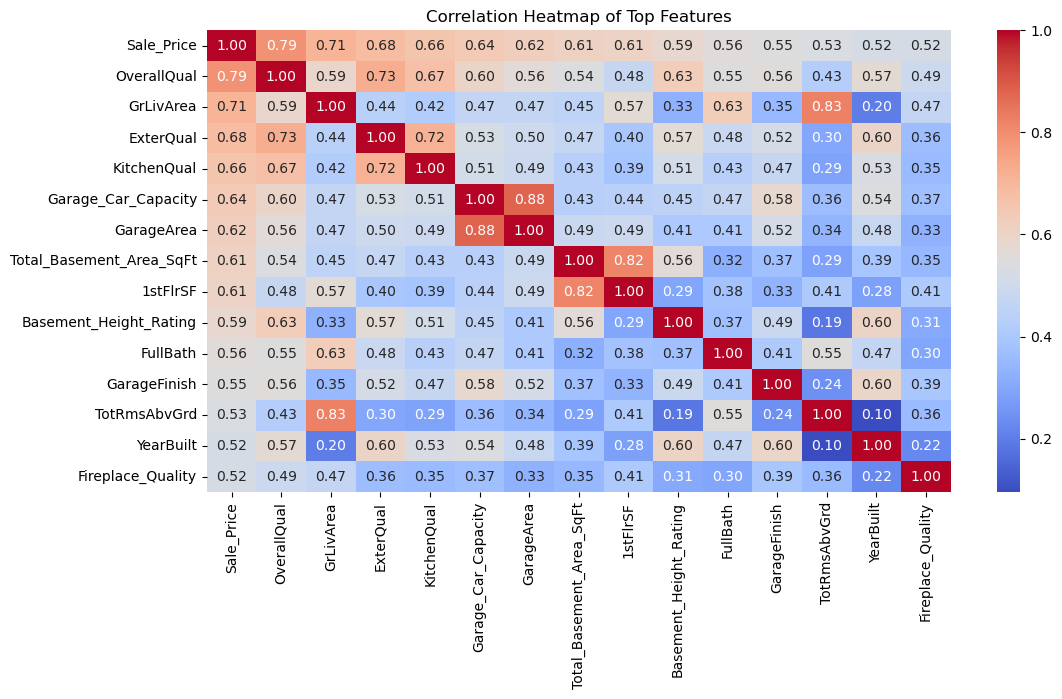

In [32]:
# Select the top features correlated with Sale_Price
top_corr_features = correlation_with_price.abs().sort_values(
    ascending=False
).head(15).index

# Create correlation matrix
corr_matrix = df[top_corr_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Top Features")
plt.show()

### Correlation Analysis

A correlation analysis was performed to identify numerical features that have a strong linear relationship with house sale price. The correlation heatmap helps identify potentially important predictors and also highlights relationships between features themselves.

Features with higher positive correlation with `Sale_Price` tend to be associated with higher house prices, while negative correlations indicate an inverse linear relationship. Correlation does not imply causation, so these results are used as an exploratory tool rather than as proof of a feature's impact on price.

In [34]:
# Separate features (X) and target variable (y)

X = df.drop('Sale_Price', axis=1)
y = df['Sale_Price']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1460, 218)
Target (y) shape: (1460,)


In [35]:
# Check the target variable

print("Target variable:", y.name)
print("\nTarget statistics:")
print(y.describe())

Target variable: Sale_Price

Target statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: Sale_Price, dtype: float64


In [36]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1168, 218)
Testing features: (292, 218)
Training target: (1168,)
Testing target: (292,)


In [37]:
# Check for missing values in training and testing data

missing_train = X_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print("Missing values in training data:")
print(missing_train)

print("\nTotal missing values in training data:", X_train.isnull().sum().sum())

Missing values in training data:
Series([], dtype: int64)

Total missing values in training data: 0


In [38]:
# Check missing values in testing data

missing_test = X_test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print("Missing values in testing data:")
print(missing_test)

print("\nTotal missing values in testing data:", X_test.isnull().sum().sum())

Missing values in testing data:
Series([], dtype: int64)

Total missing values in testing data: 0


In [39]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [40]:
# Make predictions on the test data
y_pred_linear = linear_model.predict(X_test)

print("First 10 predictions:")
print(y_pred_linear[:10])

First 10 predictions:
[157591.36634175 343317.55584746  94084.39749956 181107.38264876
 297811.24242208  74796.39619886 239980.84691487 141825.56940842
  66033.03214931 154045.56285201]


In [41]:
# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MSE  : {mse_linear:,.2f}")
print(f"RMSE : {rmse_linear:,.2f}")
print(f"R²   : {r2_linear:.4f}")

Linear Regression Performance
--------------------------------
MSE  : 2,685,644,982.09
RMSE : 51,823.21
R²   : 0.6499


## Actual vs Predicted Prices

The actual house prices are compared with the prices predicted by the Linear Regression model. A scatter plot is used to visualize how closely the predicted prices match the actual prices.

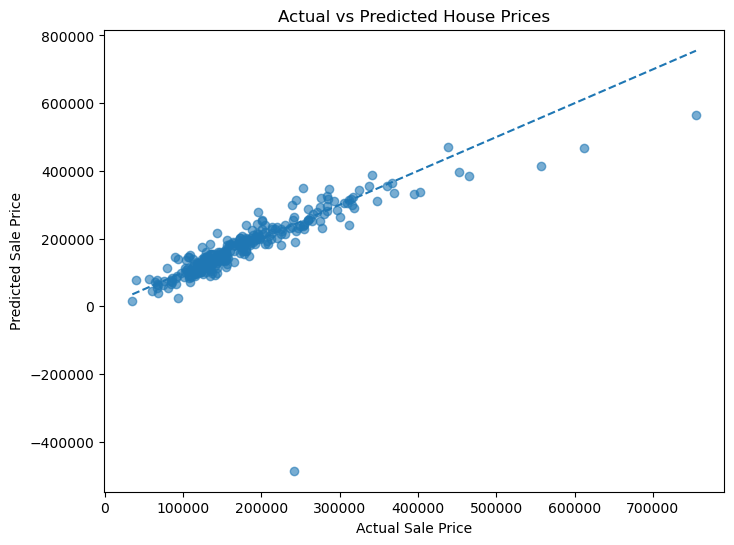

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Residual Analysis

Residuals represent the difference between the actual and predicted house prices. A residual plot is used to check whether the prediction errors are randomly distributed around zero.

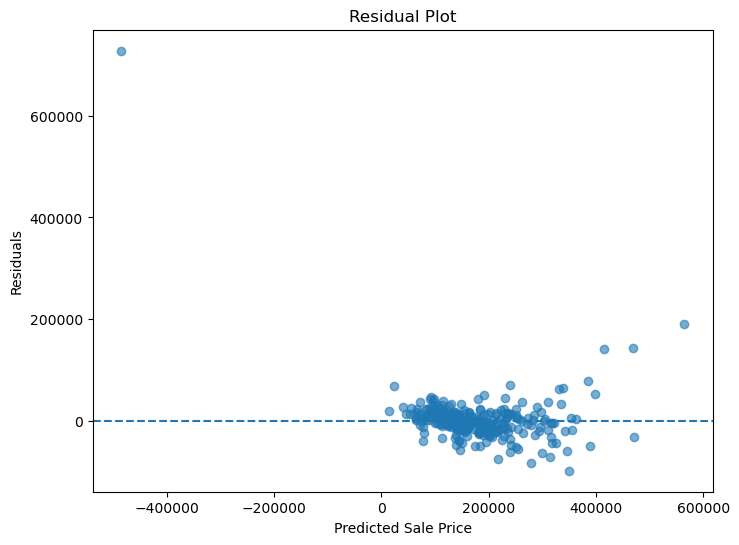

In [45]:
# Calculate residuals
residuals = y_test - y_pred_linear

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_linear, residuals, alpha=0.6)

# Zero-error reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Linear Regression Coefficient Analysis

The coefficients of the Linear Regression model indicate how each feature is associated with the predicted house price while keeping the other features constant. Positive coefficients increase the predicted price, whereas negative coefficients decrease it.

In [47]:
# Create a dataframe containing features and their coefficients

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear_model.coef_
})

# Sort by absolute coefficient value
coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print("Top 20 features by coefficient magnitude:")
display(coefficients.head(20))

Top 20 features by coefficient magnitude:


,Feature,Coefficient,Absolute_Coefficient
131,RoofMatl_WdShngl,708392.539128,708392.539128
127,RoofMatl_Metal,680028.208430,680028.208430
125,RoofMatl_CompShg,667575.754373,667575.754373
128,RoofMatl_Roll,659602.837150,659602.837150
130,RoofMatl_WdShake,657553.336105,657553.336105
129,RoofMatl_Tar&Grv,651449.717984,651449.717984
105,Condition2_PosN,-228855.037492,228855.037492
202,MiscFeature_Othr,74929.748046,74929.748046
194,GarageType_None,71530.684084,71530.684084
187,Functional_Sev,-63368.072454,63368.072454


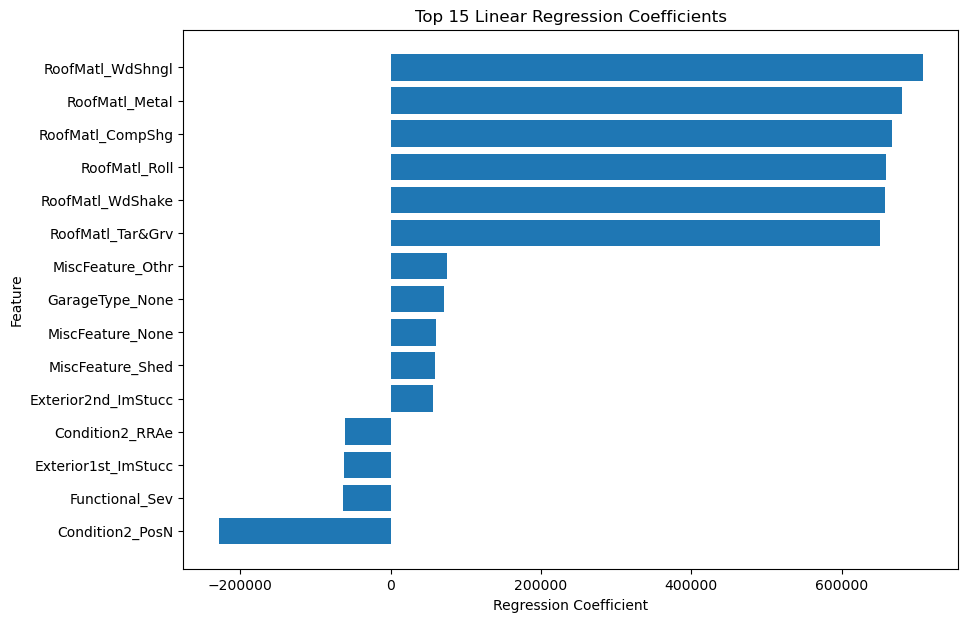

In [48]:
top_coefficients = coefficients.head(15).sort_values(
    by='Coefficient'
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients['Feature'],
    top_coefficients['Coefficient']
)

plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Linear Regression Coefficients")

plt.show()

## Ridge Regression Comparison

Ridge Regression is a regularized version of Linear Regression. It adds a penalty for large coefficients, which can help reduce overfitting when many features are present.

In [50]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [51]:
from sklearn.metrics import mean_squared_error, r2_score

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = mse_ridge ** 0.5
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("--------------------------------")
print(f"MSE  : {mse_ridge:,.2f}")
print(f"RMSE : {rmse_ridge:,.2f}")
print(f"R²   : {r2_ridge:.4f}")

Ridge Regression Performance
--------------------------------
MSE  : 995,211,853.49
RMSE : 31,546.98
R²   : 0.8703


In [52]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [53]:
# Make predictions on the test data

y_pred_rf = rf_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 Random Forest predictions:
[139883.08333333 324657.61333333 115889.91666667 152433.51666667
 324093.82333333  83474.60666667 212430.37       151635.70333333
  85278.39666667 129574.99666667]


In [54]:
# Evaluate Random Forest
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Random Forest metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"MSE  : {mse_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
--------------------------------
MSE  : 840,610,680.53
RMSE : 28,993.29
R²   : 0.8904


## Model Comparison

Linear Regression and Ridge Regression were evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score. Ridge Regression was included as a regularized model for comparison.

In [56]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest'],
    'MSE': [mse_linear, mse_ridge,mse_rf],
    'RMSE': [rmse_linear, rmse_ridge, rmse_rf],
    'R2 Score': [r2_linear, r2_ridge, r2_rf]
})

display(comparison)

,Model,MSE,RMSE,R2 Score
0,Linear Regression,2.685645e+09,51823.208913,0.649866
1,Ridge Regression,9.952119e+08,31546.978516,0.870252
2,Random Forest,8.406107e+08,28993.286818,0.890407


## Conclusion

This project successfully developed an end-to-end house price prediction workflow using Python, pandas, scikit-learn, Matplotlib, and Seaborn.

The dataset was explored, cleaned, and prepared by handling missing values, encoding categorical features, and performing correlation analysis. A **Linear Regression** model was trained using an 80:20 train-test split and achieved an **RMSE of $51,823.21** with an **R² score of 0.6499**.

As additional model comparisons, **Ridge Regression** achieved an **RMSE of $31,546.98** and **R² of 0.8703**, while **Random Forest Regression** achieved an **RMSE of $28,993.29** and **R² of 0.8904** on the test dataset.

Overall, this project demonstrates the complete process of data preprocessing, exploratory analysis, feature engineering, regression modeling, model evaluation, visualization, and model comparison for house price prediction.

In [58]:
import os

print(os.getcwd())

C:\Users\VIKAS


In [59]:
comparison.to_csv(
    "C:/Users/VIKAS/Documents/model_comparison.csv",
    index=False
)

print("Model comparison CSV saved successfully!")

Model comparison CSV saved successfully!
